In [ ]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

df = pd.read_csv("churn-bigml-20.csv")

Saving churn-bigml-20.csv to churn-bigml-20.csv


--- 1. Dataset Overview ---
Dataset Shape: 667 rows, 20 columns

Target Variable Distribution:
Churn
False    572
True      95
Name: count, dtype: int64

First 3 Rows:
  State  Account length  Area code International plan Voice mail plan  \
0    LA             117        408                 No              No   
1    IN              65        415                 No              No   
2    NY             161        415                 No              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                      0              184.5               97   
1                      0              129.1              137   
2                      0              332.9               67   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             31.37              351.6               80             29.89   
1             21.95              228.5               83             19.42   
2             56.59              317.8             

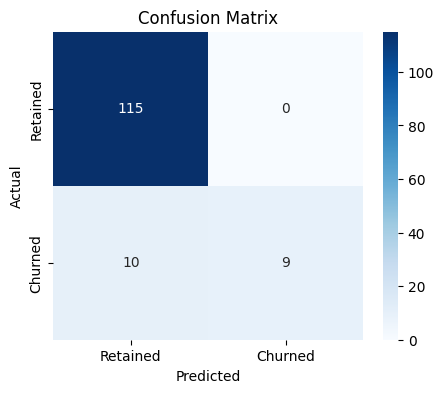

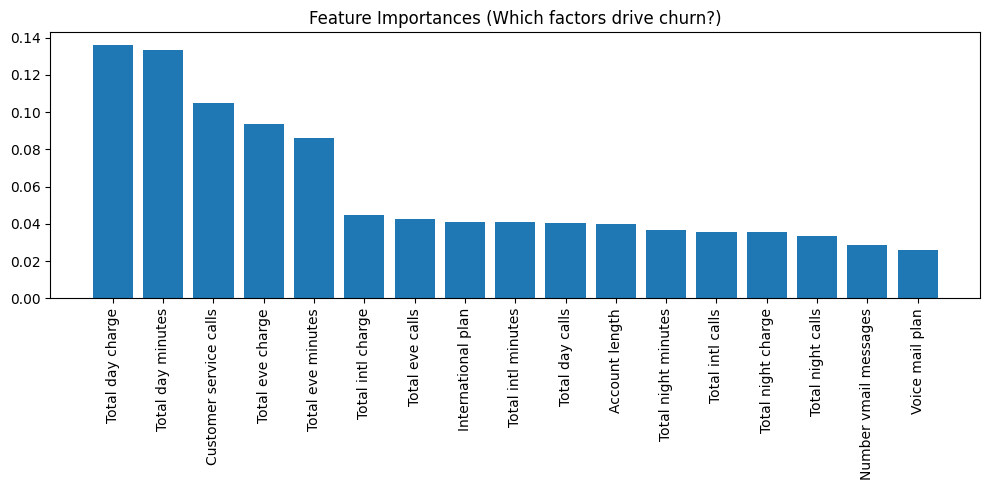

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. LOAD THE DATASET
file_path = "churn-bigml-20.csv"
df = pd.read_csv(file_path)

print("--- 1. Dataset Overview ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Target Variable Distribution:")
print(df['Churn'].value_counts(dropna=False))
print("\nFirst 3 Rows:")
print(df.head(3))

# 2. PREPROCESSING & FEATURE ENGINEERING
print("\n--- 2. Preprocessing Data ---")

# Drop unique identifier columns if they exist (unlikely to help predictions)
columns_to_drop = ['State', 'Area code', 'Phone number']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Identify binary string columns (like 'International plan', 'Voice mail plan')
binary_cols = ['International plan', 'Voice mail plan']
for col in binary_cols:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].map({'Yes': 1, 'No': 0, 'yes': 1, 'no': 0})

# Encode the target variable 'Churn' (False/True or No/Yes to 0/1)
if df['Churn'].dtype == 'object' or df['Churn'].dtype == 'bool':
    le_target = LabelEncoder()
    df['Churn'] = le_target.fit_transform(df['Churn'])

# Handle any remaining text columns automatically
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Handle missing values if any exist
df = df.fillna(df.median(numeric_only=True))

# 3. SPLIT INTO FEATURES (X) AND TARGET (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split into 80% Training and 20% Testing sets
# 'stratify=y' ensures balanced churn ratios in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. MODEL TRAINING
print("\n--- 3. Training Random Forest Classifier ---")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)
print("Model training complete!")

# 6. MODEL EVALUATION
y_pred = model.predict(X_test_scaled)

print("\n--- 4. Evaluation Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

# 7. VISUALIZE CONFUSION MATRIX
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 8. FEATURE IMPORTANCE PLOT
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,5))
plt.title("Feature Importances (Which factors drive churn?)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

print("--- 1. Hyperparameter Tuning for Random Forest ---")
# Define a grid of parameters to test
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Use Grid Search with 3-fold cross-validation to find the best settings
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, n_jobs=-1, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best parameters found: {grid_search.best_params_}")

# Evaluate the optimized Random Forest
y_pred_best_rf = best_rf.predict(X_test_scaled)
print(f"Optimized RF Accuracy: {accuracy_score(y_test, y_pred_best_rf):.4f}")


print("\n--- 2. Comparing with a Gradient Boosting Classifier ---")
# Train an alternative model to see if it performs better
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")


print("\n--- 3. Final Model Comparison Report ---")
print("Optimized Random Forest Classification Report:")
print(classification_report(y_test, y_pred_best_rf))

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))

--- 1. Hyperparameter Tuning for Random Forest ---
Best parameters found: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Optimized RF Accuracy: 0.9179

--- 2. Comparing with a Gradient Boosting Classifier ---
Gradient Boosting Accuracy: 0.9403

--- 3. Final Model Comparison Report ---
Optimized Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       115
           1       0.90      0.47      0.62        19

    accuracy                           0.92       134
   macro avg       0.91      0.73      0.79       134
weighted avg       0.92      0.92      0.91       134

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97       115
           1       1.00      0.58      0.73        19

    accuracy                           0.94       134
   macro avg       0.97      0.79      0.85       134
weighted a

In [17]:
import joblib

# Let's assume Gradient Boosting was your best model; save it and the scaler
best_model = gb_model

# Save to Colab's local session storage
joblib.dump(best_model, 'best_churn_model.pkl')
joblib.dump(scaler, 'customer_scaler.pkl')

print("--- Model & Scaler Saved Successfully! ---")
print("You can see 'best_churn_model.pkl' in your left Files sidebar now.")

--- Model & Scaler Saved Successfully! ---
You can see 'best_churn_model.pkl' in your left Files sidebar now.
